# CNN

In [1]:
import pandas as pd
import random
import torch
from torch.utils.data import Dataset
import pytorch_lightning as pl
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import os
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.image as mpimg
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

In [2]:
def plot_lightning_metrics(metrics_csv):
    df = pd.read_csv(metrics_csv)

    if "epoch" not in df.columns:
        raise ValueError("Kolom epoch tidak ada")

    df_epoch = (
        df.sort_values("step")
          .groupby("epoch", as_index=False)
          .last()
    )

    # =====================
    # LOSS
    # =====================
    plt.figure()

    if "train_loss_epoch" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["train_loss_epoch"], label="Train Loss")

    if "val_loss" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["val_loss"], label="Val Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training vs Validation Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # =====================
    # ACCURACY
    # =====================
    plt.figure()

    if "train_acc_epoch" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["train_acc_epoch"], label="Train Accuracy")

    if "val_acc" in df_epoch:
        plt.plot(df_epoch["epoch"], df_epoch["val_acc"], label="Val Accuracy")

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Training vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()



In [3]:
def visualize_cnn_results(
    model_dir,
    class_names=("tidak", "anxiety")
):
    model_dir = model_dir.rstrip("/")

    cm_files = {
        "External": os.path.join(model_dir, "cm_external.png"),
        "Internal": os.path.join(model_dir, "cm_internal.png"),
    }

    report_files = {
        "External": os.path.join(model_dir, "report_external.csv"),
        "Internal": os.path.join(model_dir, "report_internal.csv"),
    }

    # ===== SHOW CONFUSION MATRICES =====
    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"CNN {name} Confusion Matrix")
        plt.show()

    # ===== PRINT CLASSIFICATION REPORTS =====
    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f"❌ Missing {path}")
            continue

        df = pd.read_csv(path, index_col=0)

        print(f"\n=== {name.upper()} CLASSIFICATION REPORT (PERCENT) ===")
        print(f"{'Class':12s} {'Precision':>10s} {'Recall':>10s} {'F1':>10s} {'Support':>9s}")

        for i, cls in enumerate(class_names):
            p, r, f, s = df.loc[str(i), ["precision", "recall", "f1-score", "support"]]
            print(f"{cls:12s} {p*100:9.2f}% {r*100:9.2f}% {f*100:9.2f}% {int(s):9d}")

        acc = df.loc["accuracy", "precision"]
        print(f"Accuracy: {acc*100:.2f}%")

In [4]:
def prepare_balanced_subject_data_from_csv(
    csv_anxiety,
    csv_tidak,
    n_external=2,
    seed=42,
):
    random.seed(seed)

    df_a = pd.read_csv(csv_anxiety)
    df_t = pd.read_csv(csv_tidak)

    subj_a = sorted(df_a["subject"].unique())
    subj_t = sorted(df_t["subject"].unique())

    # =============================
    # BALANCE SUBJECT COUNT
    # =============================
    n_min = min(len(subj_a), len(subj_t))

    subj_a = random.sample(subj_a, n_min)
    subj_t = random.sample(subj_t, n_min)

    # =============================
    # EXTERNAL SUBJECTS
    # =============================
    ext_a = subj_a[:n_external]
    ext_t = subj_t[:n_external]

    train_a = subj_a[n_external:]
    train_t = subj_t[n_external:]

    df_train = pd.concat([
        df_a[df_a["subject"].isin(train_a)],
        df_t[df_t["subject"].isin(train_t)],
    ], ignore_index=True)

    df_external = pd.concat([
        df_a[df_a["subject"].isin(ext_a)],
        df_t[df_t["subject"].isin(ext_t)],
    ], ignore_index=True)

    print("📊 SUBJECT STATS:", {
        "balanced_per_class": n_min,
        "train_per_class": len(train_a),
        "external_per_class": n_external,
    })

    return df_train.reset_index(drop=True), df_external.reset_index(drop=True)

In [5]:
def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=labels,
                yticklabels=labels,
                cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()

In [6]:
def evaluate_model(model, loader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > 0.6).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, average=None
    )

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "support": sup,
        "cm": confusion_matrix(y_true, y_pred),
        "report": classification_report(y_true, y_pred, output_dict=True)
    }

In [18]:
class TabularDataset(Dataset):
    def __init__(self, df, feature_cols):
        self.X = torch.tensor(
            df[feature_cols].values,
            dtype=torch.float32
        )
        self.y = torch.tensor(
            (df["label"] == "anxiety").astype(int).values,
            dtype=torch.long
        )

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [17]:
class CNN(pl.LightningModule):
    def __init__(self, n_features, lr=1e-3):
        super().__init__()
        self.save_hyperparameters()

        self.conv1 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=3, padding=1)
        self.bn2   = nn.BatchNorm1d(64)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)

        self.fc = nn.Sequential(
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = x.unsqueeze(1)
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        x = torch.cat(
            [F.adaptive_avg_pool1d(x, 1),
            F.adaptive_max_pool1d(x, 1)],
            dim=1
        ).squeeze(-1)

        return self.fc(x)

    def training_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(
            logits, y,
            weight=torch.tensor([1.0, 1.1], device=self.device),
        )
        acc = (logits.argmax(1) == y).float().mean()
        self.log("train_loss", loss, prog_bar=True, on_epoch=True)
        self.log("train_acc", acc, prog_bar=True, on_epoch=True)
        return loss

    def validation_step(self, batch, _):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(1) == y).float().mean()
        self.log("val_loss", loss, prog_bar=True, on_epoch=True)
        self.log("val_acc", acc, prog_bar=True, on_epoch=True)

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=self.hparams.lr)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3, factor=0.5
        )
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }


In [23]:
def train_cnn_group(
    csv_anxiety,
    csv_tidak,
    out_dir,
    n_external=2,
    batch_size=64,
    max_epochs=50,
):
    os.makedirs(out_dir, exist_ok=True)

    # =====================================
    # 1) BALANCED SUBJECT SPLIT
    # =====================================
    df_train, df_external = prepare_balanced_subject_data_from_csv(
        csv_anxiety, csv_tidak, n_external=n_external
    )

    drop_cols = ["label", "condition", "subject", "question", "device", "frame"]
    feature_cols = [c for c in df_train.columns if c not in drop_cols]

    # =====================================
    # 2) IMPUTE + SCALE
    # =====================================
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    df_train[feature_cols] = scaler.fit_transform(
        imputer.fit_transform(df_train[feature_cols])
    )
    df_external[feature_cols] = scaler.transform(
        imputer.transform(df_external[feature_cols])
    )

    # =====================================
    # 3) INTERNAL SPLIT
    # =====================================
    df_tr, df_val = train_test_split(
        df_train,
        test_size=0.2,
        stratify=df_train["label"],
        random_state=42
    )

    train_ds = TabularDataset(df_tr, feature_cols)
    val_ds   = TabularDataset(df_val, feature_cols)
    ext_ds   = TabularDataset(df_external, feature_cols)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size)
    ext_loader   = DataLoader(ext_ds, batch_size=batch_size)

    # =====================================
    # 4) CNN MODEL
    # =====================================
    model = CNN(n_features=len(feature_cols))

    loggers = [
        CSVLogger(save_dir=out_dir, name="lightning_logs"),
        TensorBoardLogger(save_dir=out_dir, name="tb_logs")
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=out_dir,
        callbacks= [
                pl.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                mode="min"
            )
        ]
    )

    trainer.fit(model, train_loader, val_loader)

    # =====================================
    # 5) EVALUATION
    # =====================================
    print("🔎 INTERNAL (Validation)")
    res_int = evaluate_model(model, val_loader)

    print("🔎 EXTERNAL (Subject Holdout)")
    res_ext = evaluate_model(model, ext_loader)

    # Save confusion matrices
    save_confusion_matrix(
        res_int["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_internal.png"),
        "CNN Internal Confusion Matrix"
    )

    save_confusion_matrix(
        res_ext["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_external.png"),
        "CNN External Confusion Matrix"
    )

    # Save reports
    pd.DataFrame(res_int["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_internal.csv")
    )
    pd.DataFrame(res_ext["report"]).transpose().to_csv(
        os.path.join(out_dir, "report_external.csv")
    )

    trainer.save_checkpoint(os.path.join(out_dir, "cnn_model.ckpt"))

    print("✅ CNN TRAINING + EVALUATION DONE")
    print(f"📁 Output: {out_dir}")


In [10]:
torch.set_float32_matmul_precision('high')

## Before After

### Before Flatten

In [24]:
train_cnn_group(
    csv_anxiety="../features_grouped/flatten/before_anxiety.csv",
    csv_tidak="../features_grouped/flatten/before_tidak.csv",
    out_dir="models/cnn_before/flatten_balanced/",
    n_external=2
)

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 37: 100%|██████████| 1442/1442 [00:14<00:00, 96.18it/s, v_num=8_0, train_loss_step=0.397, train_acc_step=0.829, val_loss=0.341, val_acc=0.866, train_loss_epoch=0.268, train_acc_epoch=0.894]  
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING + EVALUATION DONE
📁 Output: models/cnn_before/flatten_balanced/


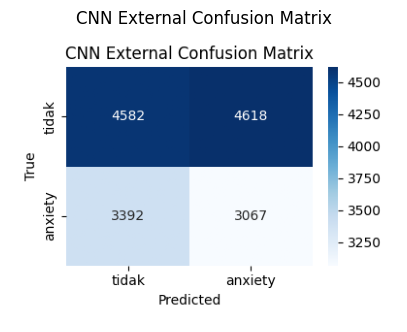

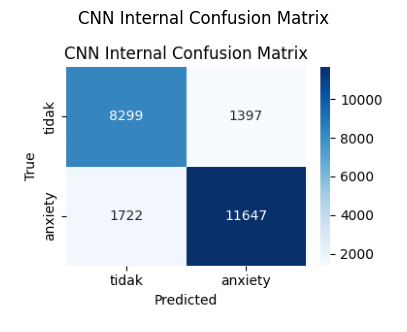


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            57.46%     49.80%     53.36%      9200
anxiety          39.91%     47.48%     43.37%      6459
Accuracy: 48.85%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            82.82%     85.59%     84.18%      9696
anxiety          89.29%     87.12%     88.19%     13369
Accuracy: 86.48%


In [25]:
visualize_cnn_results(
    "models/cnn_before/flatten_balanced/"
)

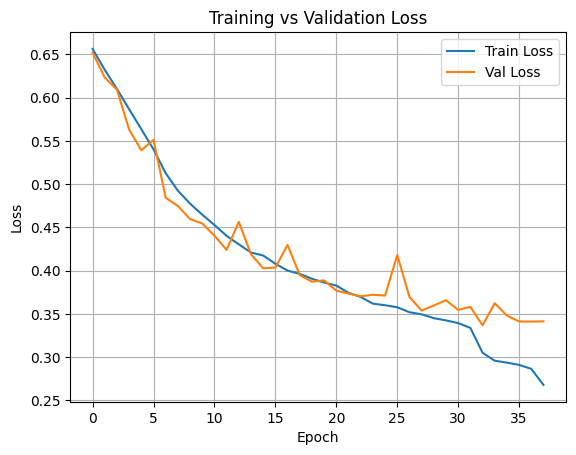

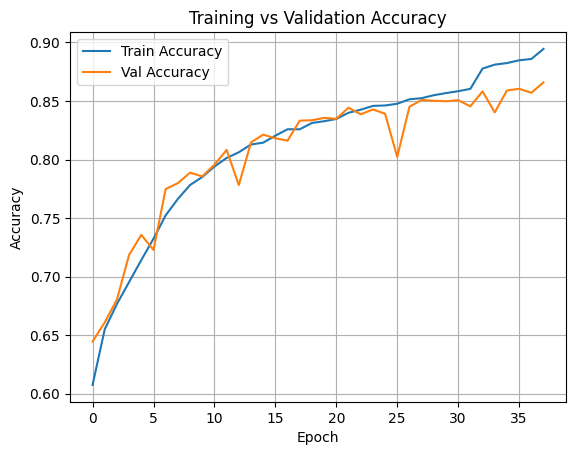

In [26]:
plot_lightning_metrics(
    "./models/cnn_before/flatten_balanced/lightning_logs/version_8/metrics.csv"
)

### After Flatten

📊 SUBJECT STATS: {'balanced_per_class': 21, 'train_per_class': 19, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 49: 100%|██████████| 966/966 [00:10<00:00, 93.01it/s, v_num=2_0, train_loss_step=0.397, train_acc_step=0.780, val_loss=0.375, val_acc=0.834, train_loss_epoch=0.368, train_acc_epoch=0.800] 

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 966/966 [00:10<00:00, 92.94it/s, v_num=2_0, train_loss_step=0.397, train_acc_step=0.780, val_loss=0.375, val_acc=0.834, train_loss_epoch=0.368, train_acc_epoch=0.800]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING + EVALUATION DONE
📁 Output: models/cnn_after/flatten_balanced/


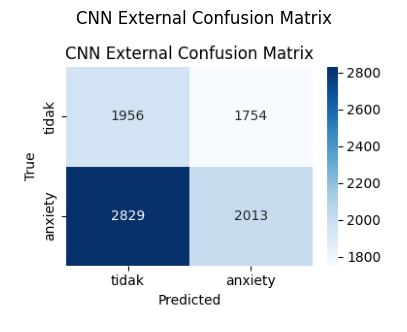

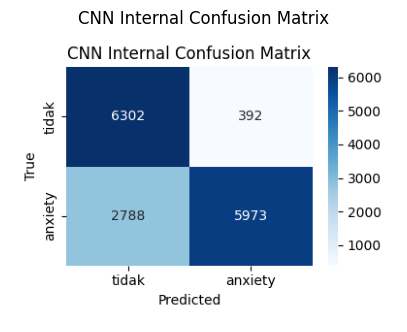


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            40.88%     52.72%     46.05%      3710
anxiety          53.44%     41.57%     46.77%      4842
Accuracy: 46.41%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            69.33%     94.14%     79.85%      6694
anxiety          93.84%     68.18%     78.98%      8761
Accuracy: 79.42%


In [27]:
train_cnn_group(
    csv_anxiety="../features_grouped/flatten/after_anxiety.csv",
    csv_tidak="../features_grouped/flatten/after_tidak.csv",
    out_dir="models/cnn_after/flatten_balanced/",
    n_external=2
)

visualize_cnn_results(
    "models/cnn_after/flatten_balanced/"
)

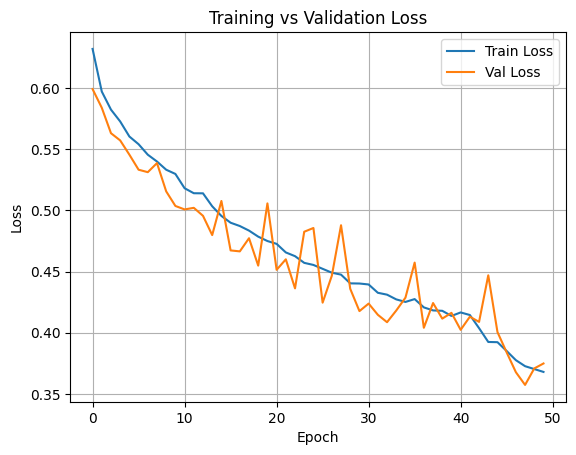

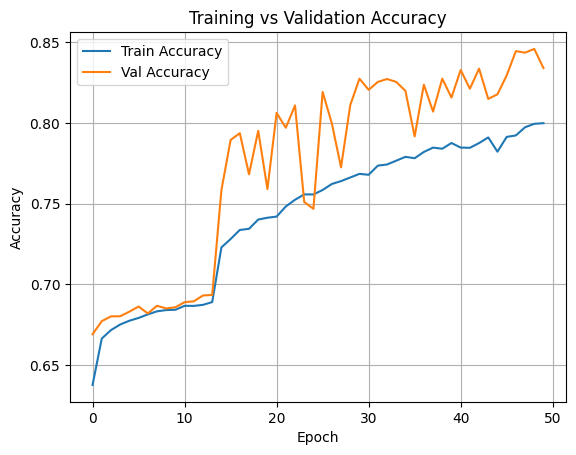

In [28]:
plot_lightning_metrics(
    "./models/cnn_after/flatten_balanced/lightning_logs/version_2/metrics.csv"
)

### Before Quadran

📊 SUBJECT STATS: {'balanced_per_class': 24, 'train_per_class': 22, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 27: 100%|██████████| 1442/1442 [00:10<00:00, 135.32it/s, v_num=1_0, train_loss_step=0.604, train_acc_step=0.600, val_loss=0.636, val_acc=0.638, train_loss_epoch=0.596, train_acc_epoch=0.670]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING + EVALUATION DONE
📁 Output: models/cnn_before/quadran_balanced/


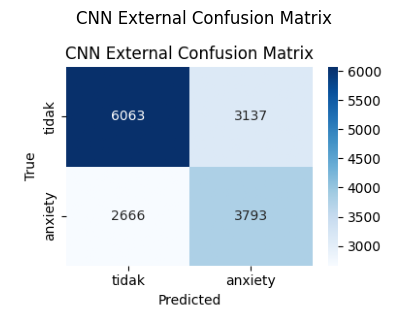

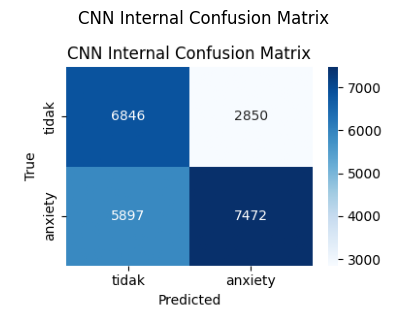


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            69.46%     65.90%     67.63%      9200
anxiety          54.73%     58.72%     56.66%      6459
Accuracy: 62.94%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            53.72%     70.61%     61.02%      9696
anxiety          72.39%     55.89%     63.08%     13369
Accuracy: 62.08%


In [29]:
train_cnn_group(
    csv_anxiety="../features_grouped/quadran/before_anxiety.csv",
    csv_tidak="../features_grouped/quadran/before_tidak.csv",
    out_dir="models/cnn_before/quadran_balanced/",
    n_external=2
)

visualize_cnn_results(
    "models/cnn_before/quadran_balanced/"
)

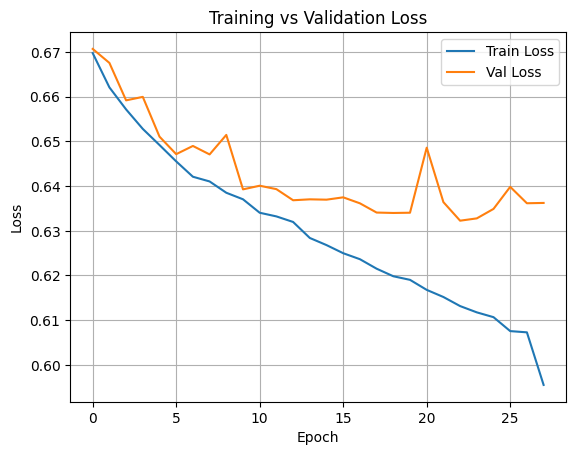

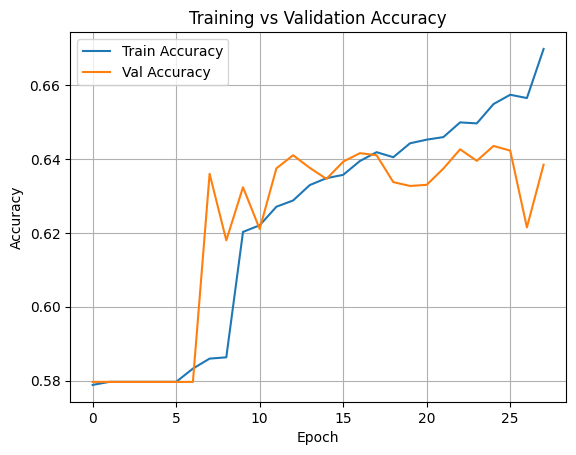

In [30]:
plot_lightning_metrics(
    "./models/cnn_before/quadran_balanced/lightning_logs/version_1/metrics.csv"
)

### After Quadran

📊 SUBJECT STATS: {'balanced_per_class': 21, 'train_per_class': 19, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Epoch 21: 100%|██████████| 966/966 [00:07<00:00, 136.43it/s, v_num=1_0, train_loss_step=0.508, train_acc_step=0.746, val_loss=0.595, val_acc=0.668, train_loss_epoch=0.544, train_acc_epoch=0.686]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING + EVALUATION DONE
📁 Output: models/cnn_after/quadran_balanced/


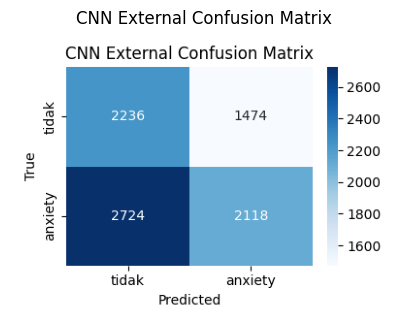

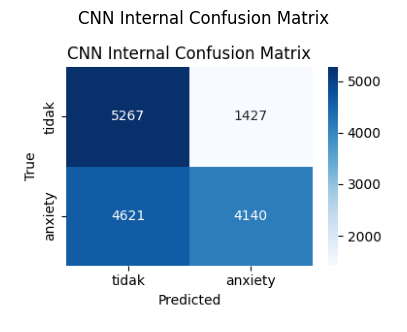


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            45.08%     60.27%     51.58%      3710
anxiety          58.96%     43.74%     50.23%      4842
Accuracy: 50.91%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            53.27%     78.68%     63.53%      6694
anxiety          74.37%     47.25%     57.79%      8761
Accuracy: 60.87%


In [31]:
train_cnn_group(
    csv_anxiety="../features_grouped/quadran/after_anxiety.csv",
    csv_tidak="../features_grouped/quadran/after_tidak.csv",
    out_dir="models/cnn_after/quadran_balanced/",
    n_external=2
)

visualize_cnn_results(
    "models/cnn_after/quadran_balanced/"
)

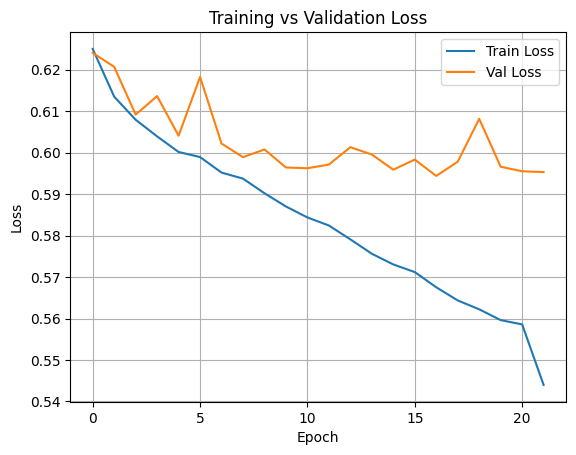

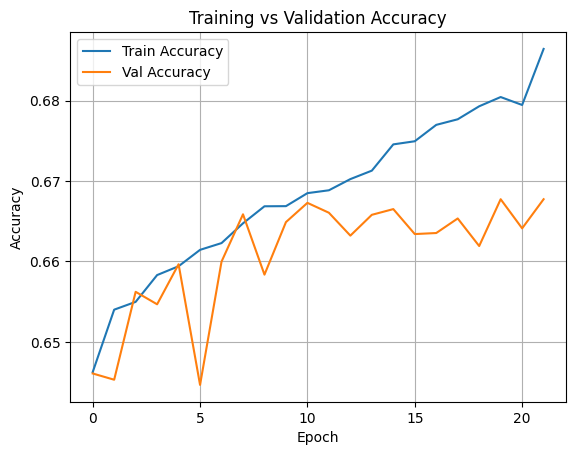

In [32]:
plot_lightning_metrics(
    "./models/cnn_after/quadran_balanced/lightning_logs/version_1/metrics.csv"
)

## Merged

In [35]:
import numpy as np

In [36]:
def balance_dataframe_by_label(df, label_col="label", random_state=42):
    counts = df[label_col].value_counts()
    min_count = counts.min()

    dfs = []
    for label in counts.index:
        dfs.append(
            df[df[label_col] == label]
            .sample(n=min_count, random_state=random_state)
        )

    return pd.concat(dfs).reset_index(drop=True)

In [37]:
def prepare_balanced_subject_data(df, n_external=2, random_state=42):
    """
    Split data by subject with balanced classes.
    - n_external: jumlah subject per kelas untuk external test
    """

    rng = np.random.RandomState(random_state)

    subjects_by_label = {
        label: df[df["label"] == label]["subject"].unique().tolist()
        for label in df["label"].unique()
    }

    # samakan jumlah subject per kelas
    min_subjects = min(len(v) for v in subjects_by_label.values())
    for k in subjects_by_label:
        rng.shuffle(subjects_by_label[k])
        subjects_by_label[k] = subjects_by_label[k][:min_subjects]

    # ambil external subjects
    external_subjects = []
    for k in subjects_by_label:
        external_subjects.extend(subjects_by_label[k][:n_external])

    train_subjects = []
    for k in subjects_by_label:
        train_subjects.extend(subjects_by_label[k][n_external:])

    df_external = df[df["subject"].isin(external_subjects)].reset_index(drop=True)
    df_train    = df[df["subject"].isin(train_subjects)].reset_index(drop=True)

    print("📊 SUBJECT STATS:", {
        "balanced_per_class": min_subjects,
        "train_per_class": min_subjects - n_external,
        "external_per_class": n_external
    })

    return df_train, df_external


In [38]:
def train_cnn_merged(
    csv_all,
    out_dir,
    n_external=2,
    batch_size=64,
    max_epochs=50,
):
    os.makedirs(out_dir, exist_ok=True)

    # =========================
    # 1) LOAD CSV
    # =========================
    df_all = pd.read_csv(csv_all)

    key_cols = ["label", "subject", "condition", "question", "device", "frame"]
    feature_cols = [c for c in df_all.columns if c not in key_cols]

    # =========================
    # 2) BALANCED SUBJECT SPLIT
    # =========================
    df_train, df_external = prepare_balanced_subject_data(
        df_all, n_external=n_external
    )

    df_external = balance_dataframe_by_label(df_external)

    # =========================
    # 3) IMPUTE + SCALE (GLOBAL, RAM-SAFE)
    # =========================
    imputer = SimpleImputer(strategy="mean")
    scaler = StandardScaler()

    # CAST ke float (hindari warning & copy berulang)
    df_train[feature_cols] = df_train[feature_cols].astype("float32")
    df_external[feature_cols] = df_external[feature_cols].astype("float32")

    X_train = imputer.fit_transform(df_train[feature_cols])
    X_train = scaler.fit_transform(X_train)
    df_train.loc[:, feature_cols] = X_train

    X_ext = imputer.transform(df_external[feature_cols])
    X_ext = scaler.transform(X_ext)
    df_external.loc[:, feature_cols] = X_ext

    # =========================
    # 4) INTERNAL SPLIT
    # =========================
    df_tr, df_val = train_test_split(
        df_train,
        test_size=0.2,
        stratify=df_train["label"],
        random_state=42
    )

    train_ds = TabularDataset(df_tr, feature_cols)
    val_ds   = TabularDataset(df_val, feature_cols)
    ext_ds   = TabularDataset(df_external, feature_cols)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=15)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, num_workers=15)
    ext_loader   = DataLoader(ext_ds, batch_size=batch_size, num_workers=15)

    # =========================
    # 5) MODEL
    # =========================
    model = CNN(n_features=len(feature_cols))

    loggers = [
        CSVLogger(save_dir=out_dir, name="lightning_logs"),
        TensorBoardLogger(save_dir=out_dir, name="tb_logs")
    ]

    trainer = pl.Trainer(
        max_epochs=max_epochs,
        accelerator="gpu",
        default_root_dir=out_dir,
        logger=loggers,
        log_every_n_steps=1,
        callbacks=[
            pl.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=5,
                mode="min"
            )
        ]
    )

    trainer.fit(model, train_loader, val_loader)

    # =========================
    # 6) EVALUATION
    # =========================
    print("🔎 INTERNAL (Validation)")
    res_int = evaluate_model(model, val_loader)

    print("🔎 EXTERNAL (Subject Holdout)")
    res_ext = evaluate_model(model, ext_loader)

    save_confusion_matrix(
        res_int["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_internal.png"),
        "CNN Internal"
    )

    save_confusion_matrix(
        res_ext["cm"],
        ["tidak", "anxiety"],
        os.path.join(out_dir, "cm_external.png"),
        "CNN External"
    )

    pd.DataFrame(res_int["report"]).T.to_csv(
        os.path.join(out_dir, "report_internal.csv")
    )
    pd.DataFrame(res_ext["report"]).T.to_csv(
        os.path.join(out_dir, "report_external.csv")
    )

    trainer.save_checkpoint(os.path.join(out_dir, "cnn_model.ckpt"))

    print("✅ CNN TRAINING DONE")
    print(f"📁 Output: {out_dir}")


#### Flatten Merged

📊 SUBJECT STATS: {'balanced_per_class': 53, 'train_per_class': 51, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

Epoch 44: 100%|██████████| 3009/3009 [00:35<00:00, 84.12it/s, v_num=1_0, train_loss_step=0.590, train_acc_step=0.764, val_loss=0.485, val_acc=0.782, train_loss_epoch=0.471, train_acc_epoch=0.782]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING DONE
📁 Output: models/cnn_flatten/


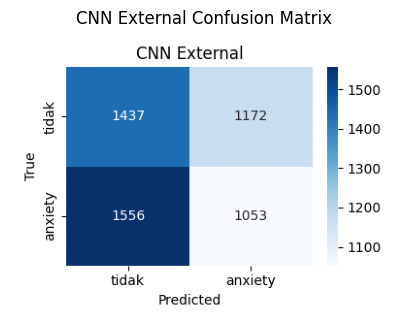

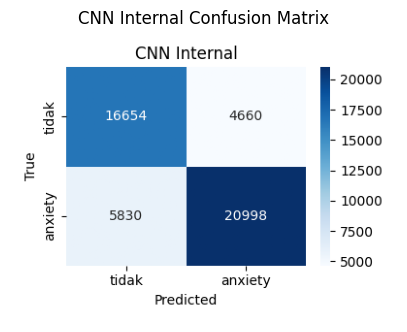


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            48.01%     55.08%     51.30%      2609
anxiety          47.33%     40.36%     43.57%      2609
Accuracy: 47.72%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            74.07%     78.14%     76.05%     21314
anxiety          81.84%     78.27%     80.01%     26828
Accuracy: 78.21%


In [39]:
train_cnn_merged(
    csv_all="../features_grouped/merged/svm_flatten_all.csv",
    out_dir="models/cnn_flatten/",
    n_external=2
)

visualize_cnn_results(
    "models/cnn_flatten/"
)

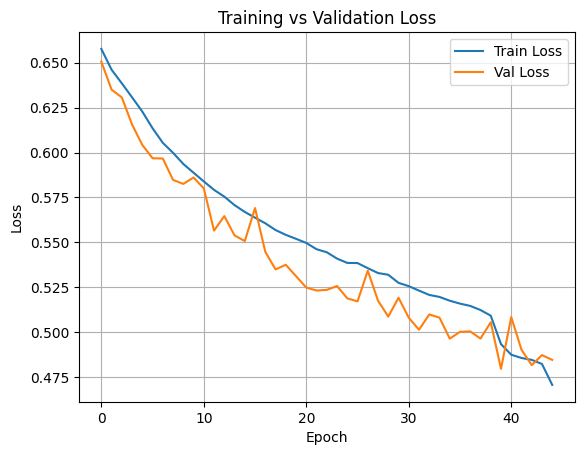

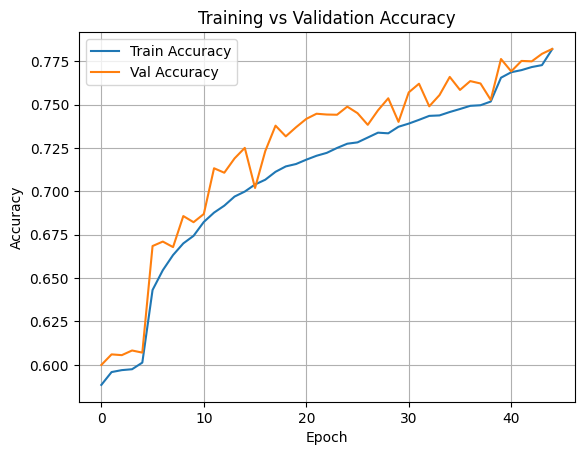

In [40]:
plot_lightning_metrics(
    "./models/cnn_flatten/lightning_logs/version_1/metrics.csv"
)

#### Quadran Merged

📊 SUBJECT STATS: {'balanced_per_class': 53, 'train_per_class': 51, 'external_per_class': 2}


💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name  | Type        | Params | Mode  | FLOPs
------------------------------------------------------
0 | conv1 | Conv1d      | 192    | train | 0    
1 | bn1   | BatchNorm1d | 64     | train | 0    
2 | conv2 | Conv1d      | 6.2 K  | train | 0    
3 | bn2   | BatchNorm1d | 128    | train | 0    
4 | conv3 | Conv1d      | 24.7 K | train | 0    
5 | bn3   | BatchNorm1d | 256    | train | 0    
6 | fc    | Sequential  | 16.6 K | train | 0    
------------------------------------------------------
48.1 K    Trainable params
0         Non-trainable params
48.1 K    Total params
0.193     Total estimated model params size (MB)
11        Modules in train mode
0       

Epoch 19: 100%|██████████| 3009/3009 [00:26<00:00, 112.55it/s, v_num=1_0, train_loss_step=0.574, train_acc_step=0.600, val_loss=0.634, val_acc=0.625, train_loss_epoch=0.616, train_acc_epoch=0.635]
🔎 INTERNAL (Validation)
🔎 EXTERNAL (Subject Holdout)


`weights_only` was not set, defaulting to `False`.


✅ CNN TRAINING DONE
📁 Output: models/cnn_quadran/


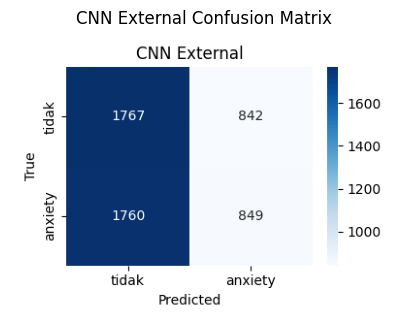

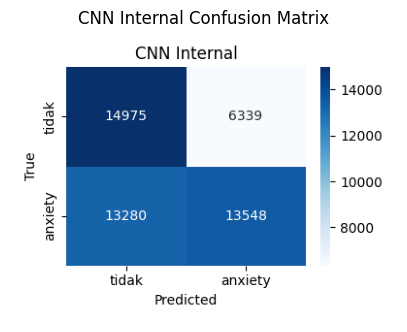


=== EXTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            50.10%     67.73%     57.59%      2609
anxiety          50.21%     32.54%     39.49%      2609
Accuracy: 50.13%

=== INTERNAL CLASSIFICATION REPORT (PERCENT) ===
Class         Precision     Recall         F1   Support
tidak            53.00%     70.26%     60.42%     21314
anxiety          68.12%     50.50%     58.00%     26828
Accuracy: 59.25%


In [42]:
train_cnn_merged(
    csv_all="../features_grouped/merged/svm_quadran_all.csv",
    out_dir="models/cnn_quadran/",
    n_external=2
)

visualize_cnn_results(
    "models/cnn_quadran/"
)

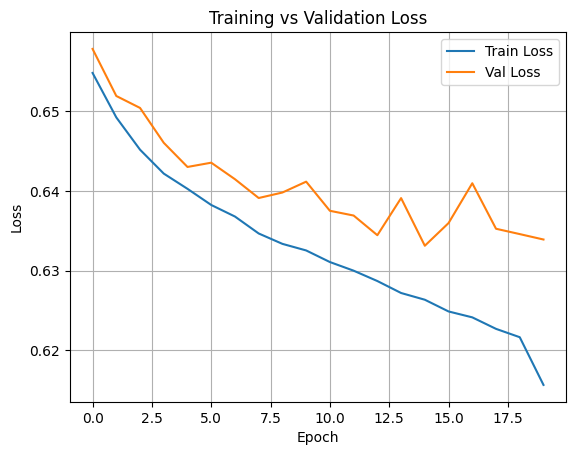

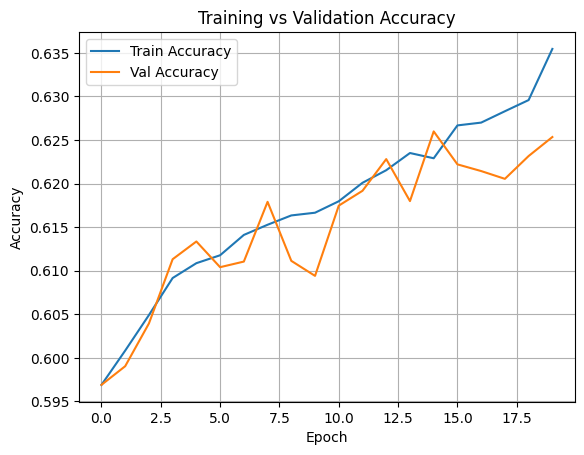

In [43]:
plot_lightning_metrics(
    "./models/cnn_quadran//lightning_logs/version_1/metrics.csv"
)

## CNN Real Test

In [ ]:
import numpy as np
import pandas as pd
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
THRESHOLD = 0.5

def inspect_feature(path):
    df = pd.read_excel(path)
    print("\nFILE:", path)
    print(df.dtypes)



# =======================
# LOAD FEATURE
# =======================
def load_feature(path):
    df = pd.read_excel(path)

    df_num = df.select_dtypes(include=[np.number])

    if df_num.shape[1] == 0:
        raise ValueError(f"Tidak ada kolom numerik di {path}")

    return df_num.values.astype(np.float32)



# =======================
# FRAME-LEVEL PREDICTION
# =======================
def predict_frame_probs(model, X):
    model.eval()
    with torch.no_grad():
        x = torch.from_numpy(X).to(DEVICE)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        anxiety_prob = probs[:, 1].cpu().numpy()
    return anxiety_prob


# =======================
# SUBJECT AGGREGATION
# =======================
def aggregate(anxiety_probs):
    return {
        "mean": float(np.mean(anxiety_probs)),
        "median": float(np.median(anxiety_probs)),
        "min": float(np.min(anxiety_probs)),
        "max": float(np.max(anxiety_probs)),
    }


# =======================
# SINGLE SUBJECT TEST
# =======================
def test_subject(subject, model, feature_key):
    X = load_feature(subject[feature_key])
    probs = predict_frame_probs(model, X)
    agg = aggregate(probs)

    pred_mean = "anxiety" if agg["mean"] >= THRESHOLD else "tidak"
    pred_median = "anxiety" if agg["median"] >= THRESHOLD else "tidak"

    print(f"\n--- {subject['name']} | {feature_key} ---")
    print(f"GT           : {subject['gt']}")
    print(f"Frames       : {len(probs)}")
    print(f"Mean prob    : {agg['mean']:.4f}")
    print(f"Median prob  : {agg['median']:.4f}")
    print(f"Min / Max    : {agg['min']:.4f} / {agg['max']:.4f}")
    print(f"Pred (mean)  : {pred_mean}")
    print(f"Pred (median): {pred_median}")


# =======================
# RUN ALL SUBJECTS
# =======================
def run_manual_test(subjects, cnn_flatten, cnn_quadran):
    print("\n==============================")
    print(" MANUAL CNN SUBJECT TEST")
    print("==============================")

    for s in subjects:
        test_subject(s, cnn_flatten, "csv_flatten")
        test_subject(s, cnn_quadran, "csv_quadran")


In [62]:
SUBJECTS = [
    # === ANXIETY ===
    {
        "name": "achmad_anfasa_rabbany",
        "gt": "anxiety",
        "csv_flatten": "./testing/features/before/anxiety/achmad_anfasa_rabbany_1765271116146/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/anxiety/achmad_anfasa_rabbany_1765271116146/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "tomi_martino_affandi",
        "gt": "anxiety",
        "csv_flatten": "./testing/features/before/anxiety/tomi_martino_affandi_1765265168562/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/anxiety/tomi_martino_affandi_1765265168562/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "nahdia_putri_safira",
        "gt": "anxiety",
        "csv_flatten": "./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/anxiety/nahdia_putri_safira_1765171578941/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "ananda_satria_putra_nugraha",
        "gt": "anxiety",
        "csv_flatten": "./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/anxiety/ananda_satria_putra_nugraha_1765167942203/poc_abs_quadran_sum.xlsx",
    },

    # === TIDAK ===
    {
        "name": "rahmad_dwi_ferdyan",
        "gt": "tidak",
        "csv_flatten": "./testing/features/before/tidak/rahmad_dwi_ferdyan_1765266777462/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/tidak/rahmad_dwi_ferdyan_1765266777462/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "dewita_anggraini",
        "gt": "tidak",
        "csv_flatten": "./testing/features/before/tidak/dewita_anggraini_1765269136205/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/tidak/dewita_anggraini_1765269136205/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "nabeel_nizam",
        "gt": "tidak",
        "csv_flatten": "./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/tidak/nabeel_nizam_1765258452319/poc_abs_quadran_sum.xlsx",
    },
    {
        "name": "tora_digda_kristiawan",
        "gt": "tidak",
        "csv_flatten": "./testing/features/before/tidak/tora_digda_kristiawan_1765184694854/poc_abs_flatten.xlsx",
        "csv_quadran": "./testing/features/before/tidak/tora_digda_kristiawan_1765184694854/poc_abs_quadran_sum.xlsx",
    },
]


In [74]:
cnn_before_flatten = CNN.load_from_checkpoint(
    "models/cnn_before/flatten_balanced/cnn_model.ckpt"
).to(DEVICE)

cnn_before_quadran = CNN.load_from_checkpoint(
    "models/cnn_before/quadran_balanced/cnn_model.ckpt"
).to(DEVICE)

cnn_after_flatten = CNN.load_from_checkpoint(
    "models/cnn_after/flatten_balanced/cnn_model.ckpt"
).to(DEVICE)

cnn_after_quadran = CNN.load_from_checkpoint(
    "models/cnn_after/quadran_balanced/cnn_model.ckpt"
).to(DEVICE)

cnn_flatten = CNN.load_from_checkpoint(
    "models/cnn_flatten/cnn_model.ckpt"
).to(DEVICE)

cnn_quadran = CNN.load_from_checkpoint(
    "models/cnn_quadran/cnn_model.ckpt"
).to(DEVICE)

In [75]:
run_manual_test(
    SUBJECTS,
    cnn_flatten=cnn_before_flatten,   # model flatten BEFORE
    cnn_quadran=cnn_before_quadran    # model quadran BEFORE
)


 MANUAL CNN SUBJECT TEST

--- achmad_anfasa_rabbany | csv_flatten ---
GT           : anxiety
Frames       : 199
Mean prob    : 0.0694
Median prob  : 0.0612
Min / Max    : 0.0161 / 0.9739
Pred (mean)  : tidak
Pred (median): tidak

--- achmad_anfasa_rabbany | csv_quadran ---
GT           : anxiety
Frames       : 199
Mean prob    : 1.0000
Median prob  : 1.0000
Min / Max    : 1.0000 / 1.0000
Pred (mean)  : anxiety
Pred (median): anxiety

--- tomi_martino_affandi | csv_flatten ---
GT           : anxiety
Frames       : 568
Mean prob    : 0.0921
Median prob  : 0.0580
Min / Max    : 0.0146 / 1.0000
Pred (mean)  : tidak
Pred (median): tidak

--- tomi_martino_affandi | csv_quadran ---
GT           : anxiety
Frames       : 568
Mean prob    : 1.0000
Median prob  : 1.0000
Min / Max    : 1.0000 / 1.0000
Pred (mean)  : anxiety
Pred (median): anxiety

--- nahdia_putri_safira | csv_flatten ---
GT           : anxiety
Frames       : 822
Mean prob    : 0.3008
Median prob  : 0.0651
Min / Max    : 0.0138 /

In [76]:
run_manual_test(
    SUBJECTS,
    cnn_flatten=cnn_after_flatten,    # model flatten AFTER
    cnn_quadran=cnn_after_quadran     # model quadran AFTER
)



 MANUAL CNN SUBJECT TEST

--- achmad_anfasa_rabbany | csv_flatten ---
GT           : anxiety
Frames       : 199
Mean prob    : 0.4428
Median prob  : 0.5375
Min / Max    : 0.0000 / 1.0000
Pred (mean)  : tidak
Pred (median): anxiety

--- achmad_anfasa_rabbany | csv_quadran ---
GT           : anxiety
Frames       : 199
Mean prob    : 0.1910
Median prob  : 0.0000
Min / Max    : 0.0000 / 1.0000
Pred (mean)  : tidak
Pred (median): tidak

--- tomi_martino_affandi | csv_flatten ---
GT           : anxiety
Frames       : 568
Mean prob    : 0.5176
Median prob  : 0.5378
Min / Max    : 0.0000 / 1.0000
Pred (mean)  : anxiety
Pred (median): anxiety

--- tomi_martino_affandi | csv_quadran ---
GT           : anxiety
Frames       : 568
Mean prob    : 0.1232
Median prob  : 0.0000
Min / Max    : 0.0000 / 1.0000
Pred (mean)  : tidak
Pred (median): tidak

--- nahdia_putri_safira | csv_flatten ---
GT           : anxiety
Frames       : 822
Mean prob    : 0.5330
Median prob  : 0.5370
Min / Max    : 0.0000 / 1

In [77]:
run_manual_test(
    SUBJECTS,
    cnn_flatten=cnn_flatten,
    cnn_quadran=cnn_quadran
)


 MANUAL CNN SUBJECT TEST

--- achmad_anfasa_rabbany | csv_flatten ---
GT           : anxiety
Frames       : 199
Mean prob    : 0.3306
Median prob  : 0.3387
Min / Max    : 0.0000 / 0.3387
Pred (mean)  : tidak
Pred (median): tidak

--- achmad_anfasa_rabbany | csv_quadran ---
GT           : anxiety
Frames       : 199
Mean prob    : 0.0000
Median prob  : 0.0000
Min / Max    : 0.0000 / 0.0000
Pred (mean)  : tidak
Pred (median): tidak

--- tomi_martino_affandi | csv_flatten ---
GT           : anxiety
Frames       : 568
Mean prob    : 0.3341
Median prob  : 0.3387
Min / Max    : 0.0000 / 0.3387
Pred (mean)  : tidak
Pred (median): tidak

--- tomi_martino_affandi | csv_quadran ---
GT           : anxiety
Frames       : 568
Mean prob    : 0.0000
Median prob  : 0.0000
Min / Max    : 0.0000 / 0.0000
Pred (mean)  : tidak
Pred (median): tidak

--- nahdia_putri_safira | csv_flatten ---
GT           : anxiety
Frames       : 822
Mean prob    : 0.3368
Median prob  : 0.3387
Min / Max    : 0.0001 / 0.7027
